# Chapter 12: Minimal surfaces

**Source span:** Pressley, Chapter 12, printed pp. 305-334, PDF pp. 307-335, Sections 12.1-12.5.

**Chapter question:** How does a surface become stationary for area, and why does the equation $H=0$ become a problem about conformal coordinates and holomorphic functions?

A minimal surface is not defined here as "the smallest surface". The computational test is local: the mean curvature vanishes. The chapter begins with Plateau's problem to explain why that test is necessary for an area minimizer, then develops examples, Gauss-map geometry, conformal parameters, and finally the Weierstrass representation.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
import trimesh
from IPython.display import Markdown, display
from plotly.subplots import make_subplots
from scipy.optimize import brentq


def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").is_dir():
            return candidate
    raise RuntimeError("Could not locate Pressley book root")


try:
    THIS_NOTEBOOK = Path(__file__).resolve()
except NameError:
    THIS_NOTEBOOK = Path.cwd() / "Elementary-Differential-Geometry-Andrew-Pressley" / "chapter-12-minimal-surfaces" / "12-minimal-surfaces.ipynb"

BOOK_ROOT = find_book_root(THIS_NOTEBOOK.resolve().parent)
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json

CHAPTER = "chapter-12"
CHAPTER_ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / CHAPTER
FIGURE_DIR = CHAPTER_ARTIFACT_ROOT / "figures"
INTERACTIVE_DIR = CHAPTER_ARTIFACT_ROOT / "interactive"
CHECK_DIR = CHAPTER_ARTIFACT_ROOT / "checks"
TABLE_DIR = CHAPTER_ARTIFACT_ROOT / "tables"
for directory in [FIGURE_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Standalone Reading Guide

Minimal surfaces are best read as a meeting point between variational geometry, curvature, complex analysis, and physical intuition. The phrase does not mean every patch has the least possible area among all competitors; it means the first variation of area vanishes, which is encoded locally by zero mean curvature. The notebook keeps those two ideas side by side: Plateau-style soap-film intuition motivates the problem, while the catenoid, helicoid, and Weierstrass examples show how the condition becomes computable.

The 3D artifacts are meant to make several equivalent tests visible. A catenoid and a helicoid look very different, yet their conformal parametrizations and zero-mean-curvature checks place them in the same associate family. The Gauss-map figure asks how normals move when the surface bends, and the Weierstrass flow diagram shows how holomorphic input data generate coordinate functions whose real parts form a minimal immersion. The Plateau threshold plot is included to remind the reader that global area behavior can change even when the local equation remains elegant.

Use the sanity checks as a glossary of minimality tests. Mean curvature should vanish, conformal coefficients should agree in the correct coordinates, coordinate functions should be harmonic, and Weierstrass data should satisfy the isotropy identity. A visual is only trusted after one of those checks ties it back to the geometry.


## Computational Translation Guide

| Book idea | Computational object in this notebook | What we check |
| --- | --- | --- |
| A surface patch $\sigma(u,v)$ | arrays or SymPy vectors for $\sigma,\sigma_u,\sigma_v$ | regularity through $\|\sigma_u\times\sigma_v\|>0$ on sampled domains |
| First and second fundamental forms | $E,F,G$ and $L,M,N$ from derivatives and the unit normal | $H=(LG-2MF+NE)/(2(EG-F^2))$ simplifies or samples to zero |
| Plateau's problem | a fixed boundary with a normal variation amplitude $\alpha$ | first variation depends on $-2H\alpha dA$ |
| Catenoid and helicoid | conformal parametrized surfaces with a shared metric factor | both have $E=G$, $F=0$, and $H=0$ |
| Gauss map | unit normal $N(u,v)$ plotted on $S^2$ | catenoid and helicoid have the same normal image, but different covering behavior |
| Conformal parametrization | coordinates where the metric is $\lambda^2(du^2+dv^2)$ | minimality becomes $\sigma_{uu}+\sigma_{vv}=0$ |
| Weierstrass representation | holomorphic data $f,g$ forming $\phi$ | $\phi_1^2+\phi_2^2+\phi_3^2=0$ and the curvature formula is nonpositive |

**Library routing.** SymPy handles exact differential identities, Plotly gives rotatable surface families, Trimesh records mesh diagnostics for the sampled surfaces, Matplotlib produces durable proof and Gauss-map diagrams, and SciPy locates the catenoid area threshold from the Plateau comparison.


In [2]:
source_span = {
    "chapter": "12 Minimal surfaces",
    "printed_pages": "305-334",
    "pdf_pages": "307-335",
    "sections": ["12.1", "12.2", "12.3", "12.4", "12.5"],
    "source_use": "orientation only; prose, diagrams, code, and checks are original",
}

visual_storyboard = [
    {
        "concept": "Plateau first variation",
        "representation": "fixed boundary, surface normal, and normal variation amplitude",
        "library": "Matplotlib",
        "artifact": "figures/plateau-first-variation.png",
        "inspection_target": "the boundary stays fixed while only the normal component changes area to first order",
        "check": "area comparison threshold for the catenoid boundary example",
    },
    {
        "concept": "minimal examples and associate family",
        "representation": "rotatable Plotly catenoid-to-helicoid family colored by Gaussian curvature",
        "library": "Plotly plus Trimesh",
        "artifact": "interactive/catenoid-helicoid-associate-family.html",
        "inspection_target": "the surface changes shape while the conformal metric factor and H=0 remain",
        "check": "SymPy H=0 identities and mesh area diagnostics",
    },
    {
        "concept": "Gauss maps",
        "representation": "normal images on the unit sphere",
        "library": "Matplotlib 3D",
        "artifact": "figures/gauss-map-catenoid-helicoid.png",
        "inspection_target": "both examples miss the poles; the helicoid covers the same normal image repeatedly",
        "check": "unit-normal residual and pole-distance bounds",
    },
    {
        "concept": "conformal minimality",
        "representation": "symbolic metric and harmonic-coordinate table",
        "library": "SymPy and pandas",
        "artifact": "tables/minimal-surface-sample-checks.csv",
        "inspection_target": "in conformal coordinates, H=0 is equivalent to coordinate-wise harmonicity",
        "check": "sigma_uu + sigma_vv vanishes for catenoid and helicoid",
    },
    {
        "concept": "Weierstrass representation",
        "representation": "data-flow diagram and two generated surfaces from g=z and g=z^2",
        "library": "SymPy, Plotly, Matplotlib",
        "artifact": "interactive/weierstrass-enneper-lab.html",
        "inspection_target": "holomorphic data produces a regular conformal minimal surface and predicts K",
        "check": "phi dot phi identity and nonpositive curvature samples",
    },
]

source_path = save_json(source_span, CHAPTER, "checks", "source-span.json", root=BOOK_ROOT / "artifacts")
storyboard_path = save_json(visual_storyboard, CHAPTER, "checks", "visual-storyboard.json", root=BOOK_ROOT / "artifacts")
display(Markdown(f"Recorded source span and storyboard under `{source_path.relative_to(BOOK_ROOT)}` and `{storyboard_path.relative_to(BOOK_ROOT)}`."))


Recorded source span and storyboard under `artifacts\chapter-12\checks\source-span.json` and `artifacts\chapter-12\checks\visual-storyboard.json`.

## Route Through The Chapter

1. **Plateau's problem:** an area minimizer with fixed boundary must be stationary for every allowed normal variation, forcing $H=0$.
2. **Examples:** the catenoid and helicoid are the two model nonplanar examples singled out by revolution and ruled-surface hypotheses.
3. **Gauss map:** when $K\ne 0$, the normal map is locally one-to-one; for a minimal surface it is conformal with scale factor $-K$.
4. **Conformal coordinates:** locally, minimal surfaces can be studied in coordinates where $E=G$ and $F=0$.
5. **Holomorphic data:** in conformal coordinates, $\phi=\sigma_u-i\sigma_v$ is holomorphic and isotropic; Weierstrass data $f,g$ solve this constraint.


## 12.1 Plateau's Problem: Why $H=0$ Appears

The first variation formula has a useful computational reading. If the boundary is fixed, tangential motion only reparametrizes the surface to first order. The normal component $\alpha=\varphi\cdot N$ is the part that changes area. The term multiplying $\alpha$ is the mean curvature density. Therefore, if area is stationary against every compactly supported normal variation, the multiplier must vanish: $H=0$.

The next cell makes two visuals. The first is a schematic of the fixed-boundary variation. The second revisits the catenoid spanning two coaxial circles: a catenoid can be minimal and still lose the global area competition to the two flat disks once the circles are too far apart.


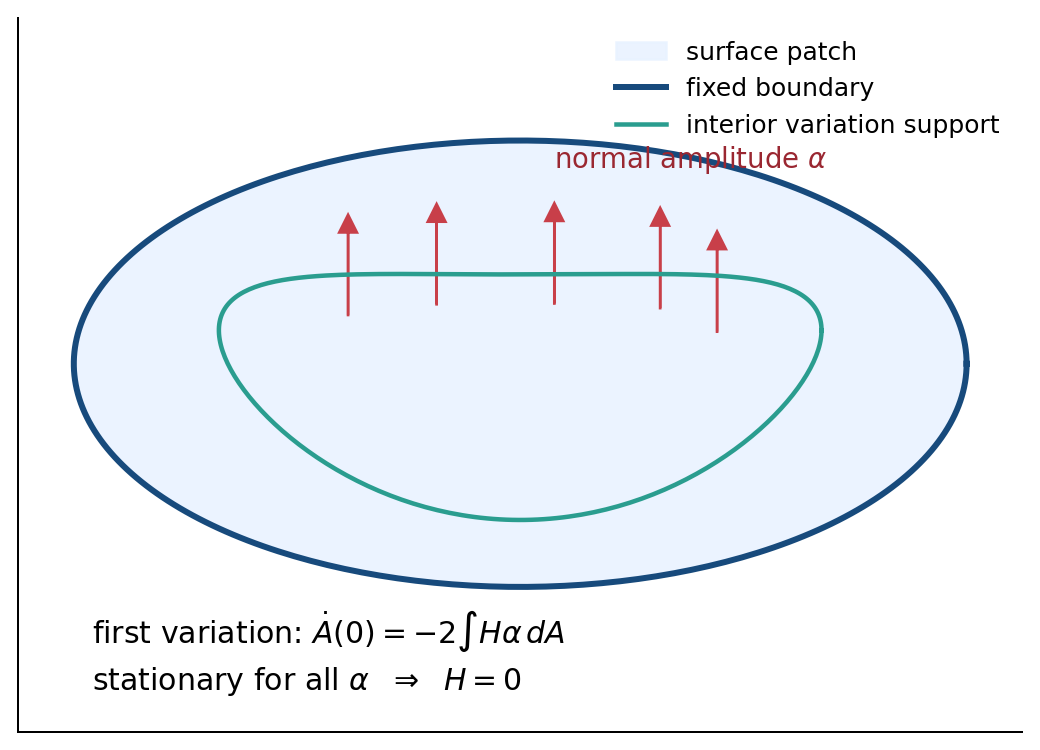

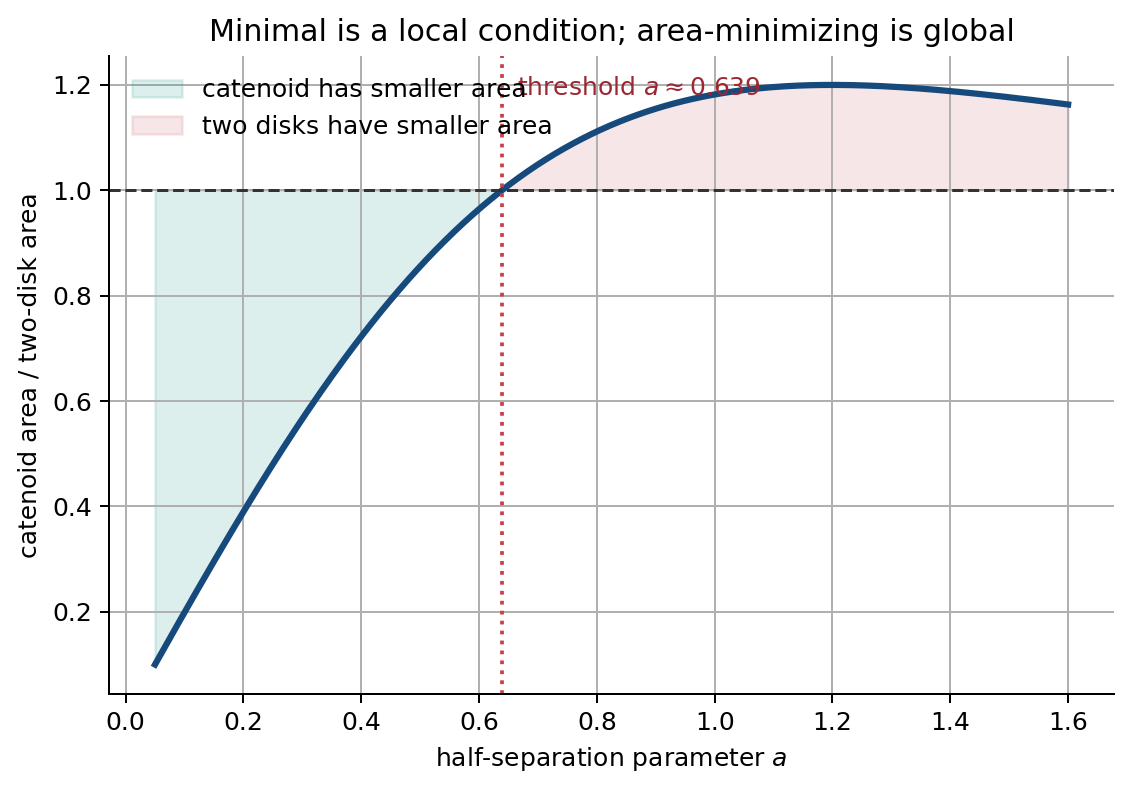

,area_threshold_a,threshold_equation_residual,ratio_at_0_4,ratio_at_1_2
0,0.639232,-2.642331e-14,0.722204,1.199679


In [3]:
# Plateau/first-variation schematic.
theta = np.linspace(0, 2 * np.pi, 300)
boundary_x = 2.0 * np.cos(theta)
boundary_y = 1.0 * np.sin(theta)
inner_x = 1.35 * np.cos(theta)
inner_y = 0.55 * np.sin(theta) + 0.15 * np.cos(2 * theta)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.fill(boundary_x, boundary_y, color="#e8f2ff", alpha=0.85, label="surface patch")
ax.plot(boundary_x, boundary_y, color="#174a7c", linewidth=2.4, label="fixed boundary")
ax.plot(inner_x, inner_y, color="#2a9d8f", linewidth=1.8, label="interior variation support")

sample_angles = np.linspace(0.2, 2.6, 5)
for angle in sample_angles:
    x = 0.9 * np.cos(angle)
    y = 0.35 * np.sin(angle) + 0.08 * np.cos(2 * angle)
    ax.arrow(x, y, 0.0, 0.45, head_width=0.08, head_length=0.08, color="#c83f49", length_includes_head=True)
ax.text(0.15, 0.88, r"normal amplitude $\alpha$", color="#9a2731", fontsize=11)
ax.text(-1.92, -1.25, r"first variation: $\dot A(0)=-2\int H\alpha\,dA$", fontsize=12)
ax.text(-1.92, -1.46, r"stationary for all $\alpha$  $\Rightarrow$  $H=0$", fontsize=12)
ax.set_aspect("equal")
ax.set_xlim(-2.25, 2.25)
ax.set_ylim(-1.65, 1.55)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="upper right", frameon=False)
plateau_variation_path = FIGURE_DIR / "plateau-first-variation.png"
fig.savefig(plateau_variation_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# Catenoid area versus the two flat disks spanning the same boundary circles.
def catenoid_area(a: np.ndarray | float) -> np.ndarray | float:
    return 2 * np.pi * (a + np.sinh(a) * np.cosh(a))


def disk_pair_area(a: np.ndarray | float) -> np.ndarray | float:
    return 2 * np.pi * np.cosh(a) ** 2


threshold = brentq(lambda x: 1 + math.exp(-2 * x) - 2 * x, 0.1, 2.0)
a_values = np.linspace(0.05, 1.6, 300)
ratio = catenoid_area(a_values) / disk_pair_area(a_values)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(a_values, ratio, color="#174a7c", linewidth=2.5)
ax.axhline(1.0, color="#333333", linewidth=1.2, linestyle="--")
ax.axvline(threshold, color="#c83f49", linewidth=1.5, linestyle=":")
ax.fill_between(a_values, ratio, 1.0, where=ratio < 1.0, color="#2a9d8f", alpha=0.16, label="catenoid has smaller area")
ax.fill_between(a_values, ratio, 1.0, where=ratio > 1.0, color="#c83f49", alpha=0.13, label="two disks have smaller area")
ax.set_xlabel(r"half-separation parameter $a$")
ax.set_ylabel("catenoid area / two-disk area")
ax.set_title("Minimal is a local condition; area-minimizing is global")
ax.legend(frameon=False, loc="upper left")
ax.text(threshold + 0.025, 1.18, rf"threshold $a\approx {threshold:.3f}$", color="#9a2731")
plateau_area_path = FIGURE_DIR / "plateau-area-threshold.png"
fig.savefig(plateau_area_path, dpi=180, bbox_inches="tight")
plt.close(fig)

plateau_checks = {
    "area_threshold_a": float(threshold),
    "threshold_equation_residual": float(1 + math.exp(-2 * threshold) - 2 * threshold),
    "ratio_at_0_4": float(catenoid_area(0.4) / disk_pair_area(0.4)),
    "ratio_at_1_2": float(catenoid_area(1.2) / disk_pair_area(1.2)),
}
plateau_checks_path = save_json(plateau_checks, CHAPTER, "checks", "plateau-area-checks.json", root=BOOK_ROOT / "artifacts")

for path in [plateau_variation_path, plateau_area_path]:
    display_artifact(path, width=760)
display(pd.DataFrame([plateau_checks]))


## 12.2 Zero Mean Curvature In The Model Examples

The catenoid and helicoid are not just pretty surfaces. They are the classification targets in two constrained families: surfaces of revolution lead to catenoids or planes, and ruled minimal surfaces lead to helicoids or planes.

For the notebook, the fastest reliable test is symbolic. The catenoid is parametrized by

$$
C(u,v)=(\cosh u\cos v,\cosh u\sin v,u),
$$

and we use a conformal helicoid parametrization conjugate to it,

$$
H(u,v)=(-\sinh u\sin v,\sinh u\cos v,-v).
$$

The signs and rigid motions are not essential; what matters is that both have the same conformal metric factor and $H=0$.


In [4]:
u, v, t = sp.symbols("u v t", real=True)


def surface_forms(sigma: sp.Matrix) -> dict[str, sp.Expr | sp.Matrix]:
    su = sigma.diff(u)
    sv = sigma.diff(v)
    suu = su.diff(u)
    suv = su.diff(v)
    svv = sv.diff(v)
    cross = su.cross(sv)
    cross_norm = sp.sqrt(sp.simplify(cross.dot(cross)))
    normal = sp.simplify(cross / cross_norm)
    E = sp.simplify(su.dot(su))
    F = sp.simplify(su.dot(sv))
    G = sp.simplify(sv.dot(sv))
    L = sp.simplify(suu.dot(normal))
    M = sp.simplify(suv.dot(normal))
    Ncoef = sp.simplify(svv.dot(normal))
    Hmean = sp.simplify((L * G - 2 * M * F + Ncoef * E) / (2 * (E * G - F**2)))
    Kgauss = sp.simplify((L * Ncoef - M**2) / (E * G - F**2))
    harmonic = sp.simplify(suu + svv)
    return {
        "su": su,
        "sv": sv,
        "normal": normal,
        "E": E,
        "F": F,
        "G": G,
        "L": L,
        "M": M,
        "N": Ncoef,
        "H": Hmean,
        "K": Kgauss,
        "harmonic": harmonic,
    }


catenoid_sigma = sp.Matrix([sp.cosh(u) * sp.cos(v), sp.cosh(u) * sp.sin(v), u])
helicoid_sigma = sp.Matrix([-sp.sinh(u) * sp.sin(v), sp.sinh(u) * sp.cos(v), -v])

cat_forms = surface_forms(catenoid_sigma)
hel_forms = surface_forms(helicoid_sigma)

symbolic_rows = []
for name, forms in [("catenoid", cat_forms), ("helicoid", hel_forms)]:
    symbolic_rows.append({
        "surface": name,
        "E": str(sp.simplify(forms["E"])),
        "F": str(sp.simplify(forms["F"])),
        "G": str(sp.simplify(forms["G"])),
        "H": str(sp.simplify(forms["H"])),
        "K": str(sp.simplify(forms["K"])),
        "sigma_uu_plus_sigma_vv": str(sp.simplify(forms["harmonic"])),
    })

symbolic_checks = {
    "catenoid_H_zero": bool(sp.simplify(cat_forms["H"]) == 0),
    "helicoid_H_zero": bool(sp.simplify(hel_forms["H"]) == 0),
    "same_metric_factor": bool(sp.simplify(cat_forms["E"] - hel_forms["E"]) == 0 and sp.simplify(cat_forms["G"] - hel_forms["G"]) == 0),
    "catenoid_harmonic": bool(all(sp.simplify(x) == 0 for x in cat_forms["harmonic"])),
    "helicoid_harmonic": bool(all(sp.simplify(x) == 0 for x in hel_forms["harmonic"])),
    "rows": symbolic_rows,
}
symbolic_checks_path = save_json(symbolic_checks, CHAPTER, "checks", "symbolic-minimality.json", root=BOOK_ROOT / "artifacts")

symbolic_df = pd.DataFrame(symbolic_rows)
symbolic_table_path = TABLE_DIR / "minimal-surface-sample-checks.csv"
symbolic_df.to_csv(symbolic_table_path, index=False)
display(symbolic_df)


,surface,E,F,G,H,K,sigma_uu_plus_sigma_vv
0,catenoid,cosh(u)**2,0,cosh(u)**2,0,-1/cosh(u)**4,"Matrix([[0], [0], [0]])"
1,helicoid,cosh(u)**2,0,cosh(u)**2,0,-1/cosh(u)**4,"Matrix([[0], [0], [0]])"


The exact table shows three facts at once: the coordinates are conformal, the mean curvature vanishes, and the coordinate functions are harmonic. The harmonicity line is the bridge to Section 12.5.

Next, rotate the saved Plotly artifact. The slider moves through the associate family joining the catenoid to its conjugate helicoid. The coloring is the Gaussian curvature $K=-\operatorname{sech}^4 u$, so the strongest bending stays at the waist/core while the surface changes shape.


In [5]:
def catenoid_grid(U: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return np.cosh(U) * np.cos(V), np.cosh(U) * np.sin(V), U


def helicoid_grid(U: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    return -np.sinh(U) * np.sin(V), np.sinh(U) * np.cos(V), -V


def associate_grid(angle: float, U: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    C = catenoid_grid(U, V)
    H = helicoid_grid(U, V)
    return tuple(np.cos(angle) * C[k] + np.sin(angle) * H[k] for k in range(3))


u_values = np.linspace(-1.65, 1.65, 76)
v_values = np.linspace(0.0, 2 * np.pi, 112)
U, V = np.meshgrid(u_values, v_values, indexing="ij")
K_color = -(1 / np.cosh(U)) ** 4

angles = np.linspace(0, np.pi / 2, 7)
X0, Y0, Z0 = associate_grid(0.0, U, V)
frames = []
for angle in angles:
    X, Y, Z = associate_grid(float(angle), U, V)
    frames.append(go.Frame(
        name=f"t={angle:.2f}",
        data=[go.Surface(x=X, y=Y, z=Z, surfacecolor=K_color, cmin=-1, cmax=0, colorscale="RdBu", showscale=True)],
    ))

fig = go.Figure(
    data=[go.Surface(x=X0, y=Y0, z=Z0, surfacecolor=K_color, cmin=-1, cmax=0, colorscale="RdBu", colorbar={"title": "K"})],
    frames=frames,
)
fig.update_layout(
    title="Catenoid-to-helicoid associate family: all frames have H=0",
    scene={
        "xaxis_title": "x",
        "yaxis_title": "y",
        "zaxis_title": "z",
        "aspectmode": "data",
        "camera": {"eye": {"x": 1.45, "y": 1.55, "z": 1.05}},
    },
    margin={"l": 0, "r": 0, "t": 46, "b": 0},
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "associate angle "},
        "steps": [
            {"label": f"{angle / np.pi:.2f}pi", "method": "animate", "args": [[f"t={angle:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]}
            for angle in angles
        ],
    }],
)
associate_html = INTERACTIVE_DIR / "catenoid-helicoid-associate-family.html"
fig.write_html(associate_html, include_plotlyjs="cdn", full_html=True)


def mesh_from_grid(X: np.ndarray, Y: np.ndarray, Z: np.ndarray) -> trimesh.Trimesh:
    rows, cols = X.shape
    vertices = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    for i in range(rows - 1):
        for j in range(cols - 1):
            a0 = i * cols + j
            a1 = (i + 1) * cols + j
            a2 = (i + 1) * cols + (j + 1)
            a3 = i * cols + (j + 1)
            faces.append([a0, a1, a2])
            faces.append([a0, a2, a3])
    return trimesh.Trimesh(vertices=vertices, faces=np.asarray(faces), process=False)


mesh_diagnostics = {}
for name, angle in [("catenoid", 0.0), ("middle_associate", float(np.pi / 4)), ("helicoid", float(np.pi / 2))]:
    X, Y, Z = associate_grid(angle, U, V)
    mesh = mesh_from_grid(X, Y, Z)
    mesh_diagnostics[name] = {
        "vertices": int(len(mesh.vertices)),
        "faces": int(len(mesh.faces)),
        "area_sample_patch": float(mesh.area),
        "euler_number_rectangular_patch": int(mesh.euler_number),
        "watertight": bool(mesh.is_watertight),
    }
mesh_diagnostics_path = save_json(mesh_diagnostics, CHAPTER, "checks", "mesh-diagnostics.json", root=BOOK_ROOT / "artifacts")

display_artifact(associate_html, width="100%", height=660)
display(pd.DataFrame(mesh_diagnostics).T)


,vertices,faces,area_sample_patch,euler_number_rectangular_patch,watertight
catenoid,8512,16650,52.879486,1,False
middle_associate,8512,16650,52.881706,1,False
helicoid,8512,16650,52.883926,1,False


## 12.3 Gauss Maps Of Minimal Surfaces

For an oriented surface, the Gauss map sends a point to its unit normal. On a minimal surface with nonzero Gaussian curvature, the shape operator has trace zero and determinant $K$, so its square is a scalar multiple of the identity. That is the proof mechanism behind the conformality of the Gauss map:

$$
G^*\langle\ ,\ \rangle=-K\langle\ ,\ \rangle.
$$

The figure below samples the catenoid and helicoid normals and places them on the unit sphere. Inspect two things: both images avoid the north and south poles on this finite sample, and the helicoid reuses the same normal directions as $v$ winds.


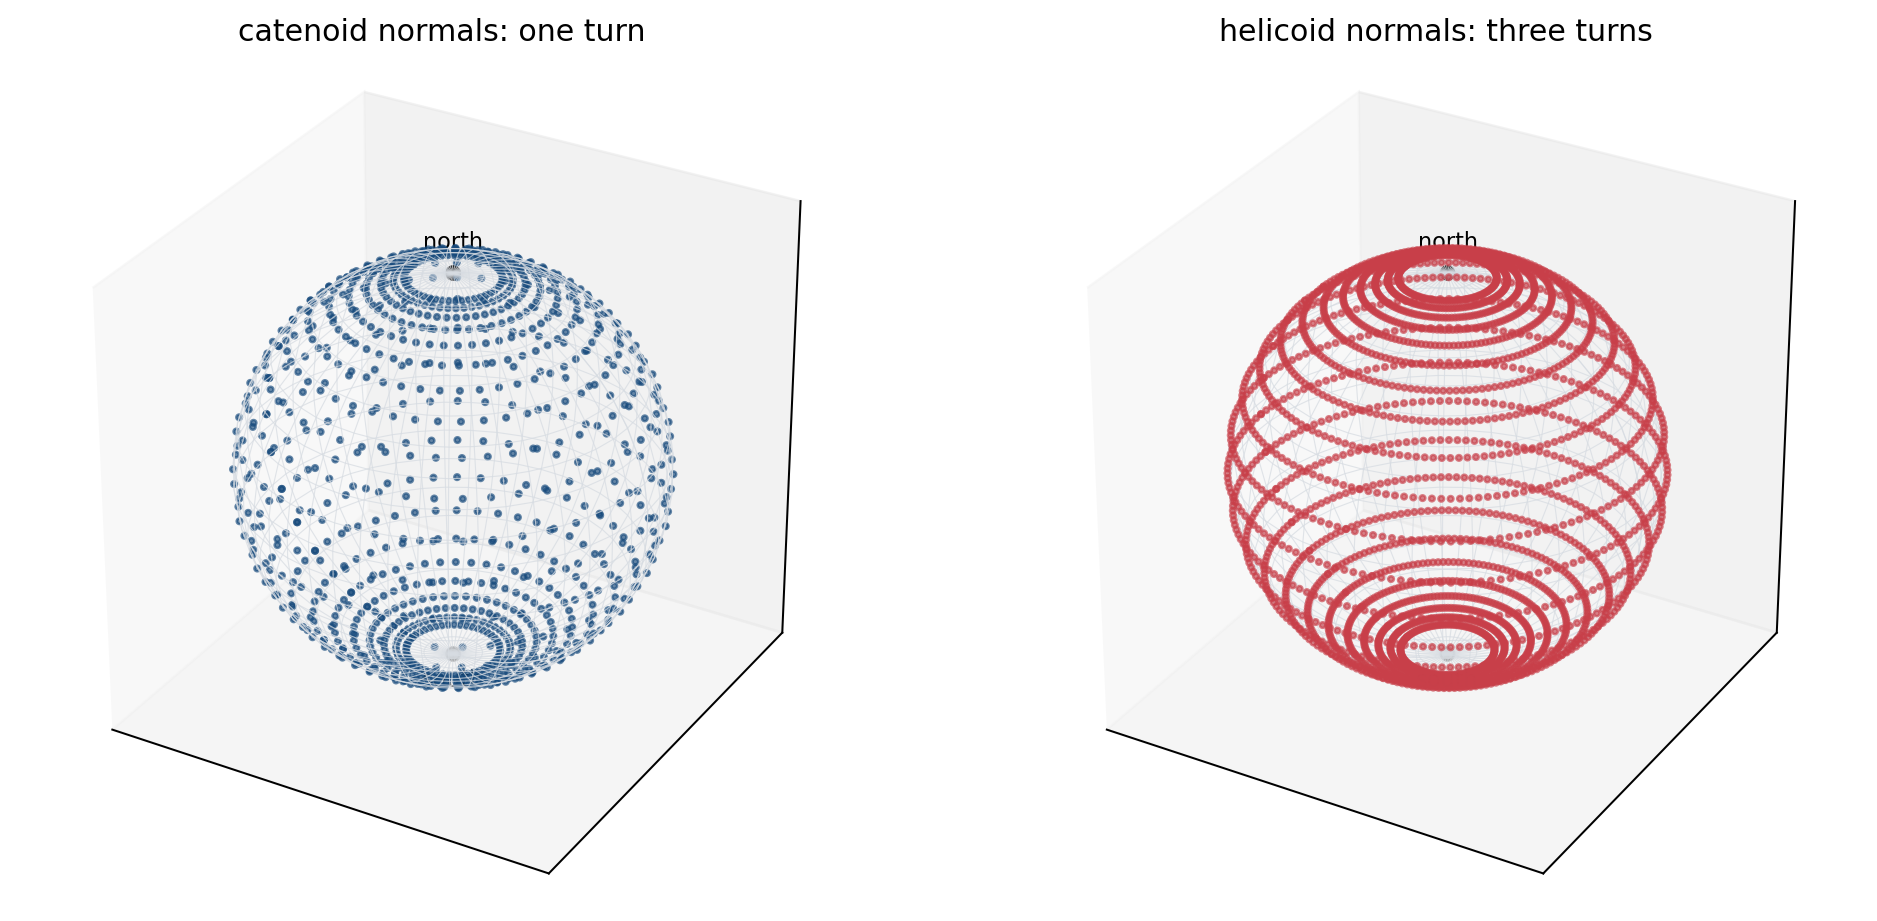

,catenoid_unit_normal_max_error,helicoid_unit_normal_max_error,sampled_catenoid_max_abs_z,sampled_helicoid_max_abs_z,helicoid_v_turns_sampled,same_formula_for_sampled_normals
0,2.220446e-16,2.220446e-16,0.975743,0.975743,3,True


In [6]:
def catenoid_normal(U: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    sech = 1 / np.cosh(U)
    return -sech * np.cos(V), -sech * np.sin(V), np.tanh(U)


def helicoid_normal(U: np.ndarray, V: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    sech = 1 / np.cosh(U)
    return -sech * np.cos(V), -sech * np.sin(V), np.tanh(U)


u_gauss = np.linspace(-2.2, 2.2, 23)
v_cat = np.linspace(0, 2 * np.pi, 48)
v_hel = np.linspace(0, 6 * np.pi, 144)
Uc, Vc = np.meshgrid(u_gauss, v_cat, indexing="ij")
Uh, Vh = np.meshgrid(u_gauss, v_hel, indexing="ij")
Nc = catenoid_normal(Uc, Vc)
Nh = helicoid_normal(Uh, Vh)

fig = plt.figure(figsize=(11.2, 5.2))
for idx, (title, normal_data, color) in enumerate([
    ("catenoid normals: one turn", Nc, "#174a7c"),
    ("helicoid normals: three turns", Nh, "#c83f49"),
], start=1):
    ax = fig.add_subplot(1, 2, idx, projection="3d")
    sphere_u = np.linspace(0, 2 * np.pi, 48)
    sphere_v = np.linspace(0, np.pi, 24)
    Sx = np.outer(np.cos(sphere_u), np.sin(sphere_v))
    Sy = np.outer(np.sin(sphere_u), np.sin(sphere_v))
    Sz = np.outer(np.ones_like(sphere_u), np.cos(sphere_v))
    ax.plot_wireframe(Sx, Sy, Sz, color="#d7dce2", linewidth=0.45, alpha=0.75)
    ax.scatter(normal_data[0].ravel(), normal_data[1].ravel(), normal_data[2].ravel(), s=5, alpha=0.65, color=color)
    ax.scatter([0, 0], [0, 0], [1, -1], color="#222222", s=28)
    ax.text(0, 0, 1.12, "north", ha="center", fontsize=9)
    ax.text(0, 0, -1.18, "south", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
fig.tight_layout()
gauss_map_path = FIGURE_DIR / "gauss-map-catenoid-helicoid.png"
fig.savefig(gauss_map_path, dpi=180, bbox_inches="tight")
plt.close(fig)

cat_norm_lengths = np.sqrt(sum(part**2 for part in Nc))
hel_norm_lengths = np.sqrt(sum(part**2 for part in Nh))
gauss_checks = {
    "catenoid_unit_normal_max_error": float(np.max(np.abs(cat_norm_lengths - 1))),
    "helicoid_unit_normal_max_error": float(np.max(np.abs(hel_norm_lengths - 1))),
    "sampled_catenoid_max_abs_z": float(np.max(np.abs(Nc[2]))),
    "sampled_helicoid_max_abs_z": float(np.max(np.abs(Nh[2]))),
    "helicoid_v_turns_sampled": 3,
    "same_formula_for_sampled_normals": bool(np.allclose(catenoid_normal(Uc, Vc), helicoid_normal(Uc, Vc))),
}
gauss_checks_path = save_json(gauss_checks, CHAPTER, "checks", "gauss-map-checks.json", root=BOOK_ROOT / "artifacts")

display_artifact(gauss_map_path, width=900)
display(pd.DataFrame([gauss_checks]))


## 12.4 Conformal Parametrizations

Conformal coordinates are the technical passage from surface geometry to complex analysis. In such coordinates $E=G=\lambda^2$ and $F=0$. Then the vector equation

$$
\sigma_{uu}+\sigma_{vv}=0
$$

is the minimal-surface condition. Component by component, the coordinate functions are harmonic. The catenoid and conformal helicoid above already demonstrate the pattern: both have metric $\cosh^2u(du^2+dv^2)$ and both satisfy the harmonic equation exactly.

This is why Section 12.5 can introduce $\zeta=u+iv$ and treat $\sigma_u-i\sigma_v$ as complex data.


In [7]:
conformal_checks = {
    "catenoid_E_minus_G": str(sp.simplify(cat_forms["E"] - cat_forms["G"])),
    "catenoid_F": str(sp.simplify(cat_forms["F"])),
    "catenoid_harmonic_vector": str(sp.simplify(cat_forms["harmonic"])),
    "helicoid_E_minus_G": str(sp.simplify(hel_forms["E"] - hel_forms["G"])),
    "helicoid_F": str(sp.simplify(hel_forms["F"])),
    "helicoid_harmonic_vector": str(sp.simplify(hel_forms["harmonic"])),
}
conformal_checks_path = save_json(conformal_checks, CHAPTER, "checks", "conformal-harmonic-checks.json", root=BOOK_ROOT / "artifacts")

display(Markdown("| check | result |\n| --- | --- |\n" + "\n".join(f"| `{k}` | `{v}` |" for k, v in conformal_checks.items())))


| check | result |
| --- | --- |
| `catenoid_E_minus_G` | `0` |
| `catenoid_F` | `0` |
| `catenoid_harmonic_vector` | `Matrix([[0], [0], [0]])` |
| `helicoid_E_minus_G` | `0` |
| `helicoid_F` | `0` |
| `helicoid_harmonic_vector` | `Matrix([[0], [0], [0]])` |

## 12.5 Weierstrass Representation

In conformal coordinates define

$$
\phi=\sigma_u-i\sigma_v.
$$

Minimality makes $\phi$ holomorphic, and conformality forces the isotropic identity

$$
\phi_1^2+\phi_2^2+\phi_3^2=0.
$$

Weierstrass' representation solves this identity using a holomorphic function $f$ and a meromorphic function $g$:

$$
\phi=\left(\frac{1}{2} f(1-g^2),\frac{i}{2}f(1+g^2),fg\right).
$$

The algebraic check below is exact. The nearby diagram records the data flow from complex functions to a real minimal surface.


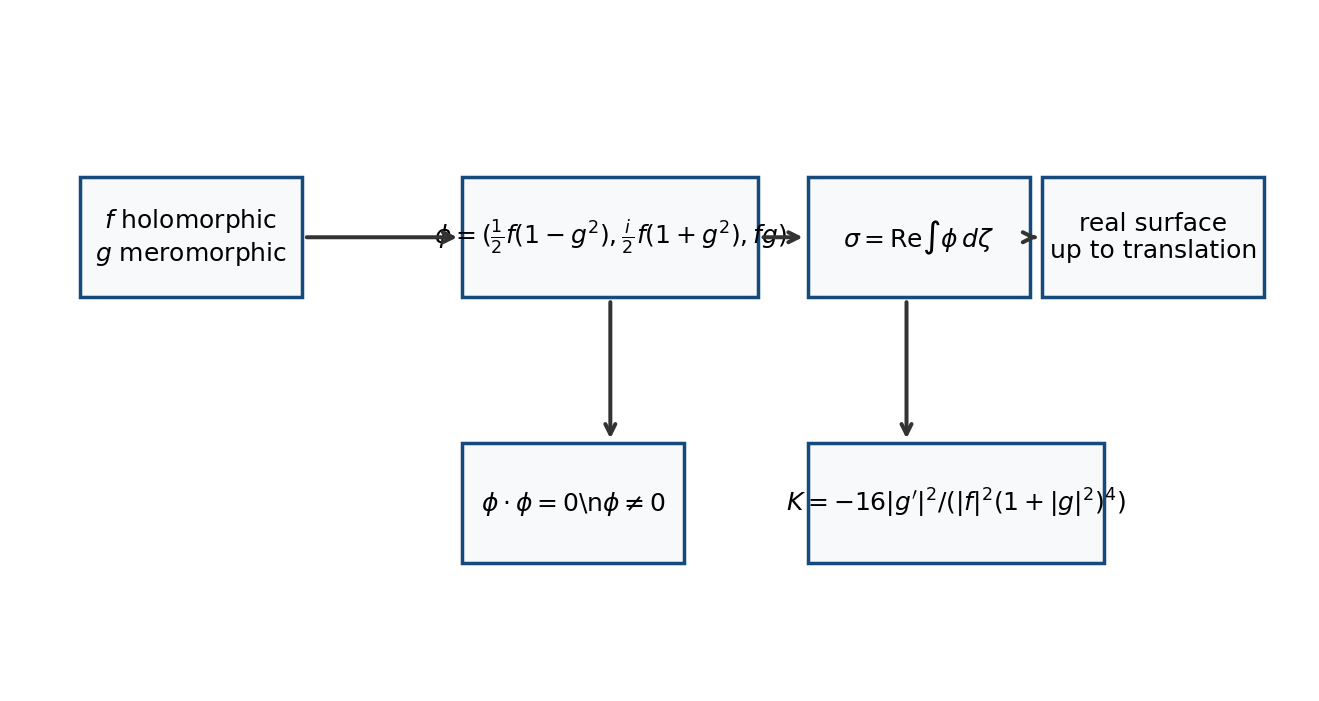

Exact isotropic check: `$\phi\cdot\phi = 0$`.

In [8]:
f_sym, g_sym = sp.symbols("f g")
I = sp.I
phi_weierstrass = sp.Matrix([
    sp.Rational(1, 2) * f_sym * (1 - g_sym**2),
    sp.Rational(1, 2) * I * f_sym * (1 + g_sym**2),
    f_sym * g_sym,
])
phi_dot_phi = sp.simplify(sum(component**2 for component in phi_weierstrass))

fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.axis("off")
boxes = {
    "f, g": (0.05, 0.58),
    "phi": (0.36, 0.58),
    "integrate": (0.64, 0.58),
    "surface": (0.83, 0.58),
    "checks": (0.36, 0.18),
    "curvature": (0.64, 0.18),
}
labels = {
    "f, g": "$f$ holomorphic\n$g$ meromorphic",
    "phi": r"$\phi=(\frac{1}{2}f(1-g^2),\frac{i}{2}f(1+g^2),fg)$",
    "integrate": r"$\sigma=\mathrm{Re}\int \phi\,d\zeta$",
    "surface": "real surface\nup to translation",
    "checks": r"$\phi\cdot\phi=0$\n$\phi\neq 0$",
    "curvature": r"$K=-16|g'|^2/(|f|^2(1+|g|^2)^4)$",
}
for key, (x, y) in boxes.items():
    width = 0.18 if key not in {"phi", "curvature"} else 0.24
    rect = plt.Rectangle((x, y), width, 0.18, facecolor="#f7f9fb", edgecolor="#174a7c", linewidth=1.4)
    ax.add_patch(rect)
    ax.text(x + width / 2, y + 0.09, labels[key], ha="center", va="center", fontsize=10)


def arrow(start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "lw": 1.6, "color": "#333333"})


arrow((0.23, 0.67), (0.36, 0.67))
arrow((0.60, 0.67), (0.64, 0.67))
arrow((0.82, 0.67), (0.83, 0.67))
arrow((0.48, 0.58), (0.48, 0.36))
arrow((0.72, 0.58), (0.72, 0.36))
ax.set_xlim(0, 1.04)
ax.set_ylim(0, 1)
weierstrass_flow_path = FIGURE_DIR / "weierstrass-data-flow.png"
fig.savefig(weierstrass_flow_path, dpi=180, bbox_inches="tight")
plt.close(fig)

weierstrass_symbolic_checks = {
    "generic_phi_dot_phi": str(phi_dot_phi),
    "generic_phi_dot_phi_is_zero": bool(phi_dot_phi == 0),
}
weierstrass_symbolic_path = save_json(weierstrass_symbolic_checks, CHAPTER, "checks", "weierstrass-symbolic-checks.json", root=BOOK_ROOT / "artifacts")

display_artifact(weierstrass_flow_path, width=900)
display(Markdown(f"Exact isotropic check: `$\\phi\\cdot\\phi = {sp.latex(phi_dot_phi)}$`."))


## Applied Lab: Build Minimal Surfaces From Weierstrass Data

The lab compares two choices with constant $f=2$ and $g(\zeta)=\zeta^p$.

- $p=1$ gives an Enneper-type surface, up to rigid motions and scaling conventions.
- $p=2$ gives a surface whose curvature formula has an isolated zero at the origin because $g'(0)=0$.

The point of the lab is not to memorize these shapes. It is to see how the geometry is encoded: $g$ controls the normal data and the curvature concentration, while the real part of the complex integral produces the surface.


In [9]:
def weierstrass_power_surface(power: int, U: np.ndarray, V: np.ndarray, scale: float = 2.0) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    z = U + 1j * V
    q = 2 * power + 1
    F1 = scale / 2 * (z - z**q / q)
    F2 = 1j * scale / 2 * (z + z**q / q)
    F3 = scale * z ** (power + 1) / (power + 1)
    g = z**power
    gp = power * z ** (power - 1)
    K = -16 * np.abs(gp) ** 2 / (scale**2 * (1 + np.abs(g) ** 2) ** 4)
    return F1.real, F2.real, F3.real, K


lab_u = np.linspace(-1.15, 1.15, 83)
lab_v = np.linspace(-1.15, 1.15, 83)
LU, LV = np.meshgrid(lab_u, lab_v, indexing="ij")

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=["g(z)=z", "g(z)=z^2"],
)
lab_checks = {}
for col, power in enumerate([1, 2], start=1):
    X, Y, Z, K = weierstrass_power_surface(power, LU, LV)
    fig.add_trace(
        go.Surface(x=X, y=Y, z=Z, surfacecolor=K, colorscale="Viridis", cmin=-4, cmax=0, showscale=(col == 2), colorbar={"title": "K"}),
        row=1,
        col=col,
    )
    center_idx = (LU.shape[0] // 2, LU.shape[1] // 2)
    lab_checks[f"power_{power}"] = {
        "K_min": float(np.min(K)),
        "K_max": float(np.max(K)),
        "K_at_center": float(K[center_idx]),
        "nonpositive_K_samples": bool(np.all(K <= 1e-12)),
        "finite_samples": bool(np.isfinite(X).all() and np.isfinite(Y).all() and np.isfinite(Z).all() and np.isfinite(K).all()),
    }
fig.update_layout(
    title="Applied lab: Weierstrass surfaces from polynomial Gauss data",
    scene={"aspectmode": "data", "camera": {"eye": {"x": 1.5, "y": 1.4, "z": 1.0}}},
    scene2={"aspectmode": "data", "camera": {"eye": {"x": 1.5, "y": 1.4, "z": 1.0}}},
    margin={"l": 0, "r": 0, "t": 54, "b": 0},
)
weierstrass_lab_html = INTERACTIVE_DIR / "weierstrass-enneper-lab.html"
fig.write_html(weierstrass_lab_html, include_plotlyjs="cdn", full_html=True)

lab_checks["symbolic_phi_dot_phi_is_zero"] = bool(phi_dot_phi == 0)
weierstrass_lab_checks_path = save_json(lab_checks, CHAPTER, "checks", "weierstrass-lab-checks.json", root=BOOK_ROOT / "artifacts")

display_artifact(weierstrass_lab_html, width="100%", height=620)
display(pd.DataFrame(lab_checks).T)


,K_min,K_max,K_at_center,nonpositive_K_samples,finite_samples
power_1,-4.0,-0.022661,-4.0,True,True
power_2,-3.544889,-0.0,-0.0,True,True
symbolic_phi_dot_phi_is_zero,True,True,True,True,True


## Takeaways

- Plateau's problem motivates $H=0$ as a stationarity condition, not as a guarantee of global area minimization.
- The catenoid and helicoid are the model nonplanar examples: one is rotational, one is ruled, and in conformal form they share the same metric factor.
- For a minimal surface with $K\ne 0$, the Gauss map is conformal with scale factor $-K$.
- Conformal coordinates turn the minimal equation into harmonic coordinate functions.
- Weierstrass data packages conformality and minimality into holomorphic functions satisfying an exact isotropic identity.


## Final Sanity Checks

The final cell checks the exact identities, verifies that every artifact exists with nonzero size, and records a compact JSON handoff for this chapter.


In [10]:
notebook_sanity = {
    "unit": CHAPTER,
    "source_span": source_span,
    "storyboard_items": [item["concept"] for item in visual_storyboard],
    "core_checks": {
        "catenoid_H_zero": symbolic_checks["catenoid_H_zero"],
        "helicoid_H_zero": symbolic_checks["helicoid_H_zero"],
        "same_metric_factor": symbolic_checks["same_metric_factor"],
        "gauss_unit_normal_max_error": max(gauss_checks["catenoid_unit_normal_max_error"], gauss_checks["helicoid_unit_normal_max_error"]),
        "weierstrass_phi_dot_phi_zero": weierstrass_symbolic_checks["generic_phi_dot_phi_is_zero"],
        "weierstrass_power_2_center_curvature": lab_checks["power_2"]["K_at_center"],
    },
}
notebook_sanity_path = save_json(notebook_sanity, CHAPTER, "checks", "notebook-sanity.json", root=BOOK_ROOT / "artifacts")

artifact_paths = [
    source_path,
    storyboard_path,
    plateau_variation_path,
    plateau_area_path,
    plateau_checks_path,
    notebook_sanity_path,
    symbolic_checks_path,
    symbolic_table_path,
    associate_html,
    mesh_diagnostics_path,
    gauss_map_path,
    gauss_checks_path,
    conformal_checks_path,
    weierstrass_flow_path,
    weierstrass_symbolic_path,
    weierstrass_lab_html,
    weierstrass_lab_checks_path,
]

for path in artifact_paths:
    min_bytes = 64 if path.suffix.lower() in {".json", ".csv"} else 512
    assert_artifact(path, min_bytes=min_bytes)

assert symbolic_checks["catenoid_H_zero"]
assert symbolic_checks["helicoid_H_zero"]
assert symbolic_checks["same_metric_factor"]
assert symbolic_checks["catenoid_harmonic"]
assert symbolic_checks["helicoid_harmonic"]
assert abs(plateau_checks["threshold_equation_residual"]) < 1e-12
assert plateau_checks["ratio_at_0_4"] < 1.0
assert plateau_checks["ratio_at_1_2"] > 1.0
assert gauss_checks["catenoid_unit_normal_max_error"] < 1e-12
assert gauss_checks["helicoid_unit_normal_max_error"] < 1e-12
assert weierstrass_symbolic_checks["generic_phi_dot_phi_is_zero"]
assert lab_checks["power_1"]["nonpositive_K_samples"]
assert lab_checks["power_2"]["nonpositive_K_samples"]
assert abs(lab_checks["power_2"]["K_at_center"]) < 1e-6

final_sanity = {
    "source_span": source_span,
    "artifact_count": len(artifact_paths),
    "artifacts": [str(path.relative_to(BOOK_ROOT)) for path in artifact_paths],
    "symbolic_checks": {
        "catenoid_H_zero": symbolic_checks["catenoid_H_zero"],
        "helicoid_H_zero": symbolic_checks["helicoid_H_zero"],
        "same_metric_factor": symbolic_checks["same_metric_factor"],
        "weierstrass_phi_dot_phi_zero": weierstrass_symbolic_checks["generic_phi_dot_phi_is_zero"],
    },
    "numeric_checks": {
        "area_threshold_a": plateau_checks["area_threshold_a"],
        "gauss_unit_normal_max_error": max(gauss_checks["catenoid_unit_normal_max_error"], gauss_checks["helicoid_unit_normal_max_error"]),
        "power_2_center_curvature": lab_checks["power_2"]["K_at_center"],
    },
}
final_sanity_path = save_json(final_sanity, CHAPTER, "checks", "final-sanity.json", root=BOOK_ROOT / "artifacts")
assert_artifact(final_sanity_path, min_bytes=256)

display(Markdown(f"Final sanity checks passed; wrote `{final_sanity_path.relative_to(BOOK_ROOT)}`."))
final_sanity


Final sanity checks passed; wrote `artifacts\chapter-12\checks\final-sanity.json`.

{'source_span': {'chapter': '12 Minimal surfaces',
  'printed_pages': '305-334',
  'pdf_pages': '307-335',
  'sections': ['12.1', '12.2', '12.3', '12.4', '12.5'],
  'source_use': 'orientation only; prose, diagrams, code, and checks are original'},
 'artifact_count': 17,
 'artifacts': ['artifacts\\chapter-12\\checks\\source-span.json',
  'artifacts\\chapter-12\\checks\\visual-storyboard.json',
  'artifacts\\chapter-12\\figures\\plateau-first-variation.png',
  'artifacts\\chapter-12\\figures\\plateau-area-threshold.png',
  'artifacts\\chapter-12\\checks\\plateau-area-checks.json',
  'artifacts\\chapter-12\\checks\\notebook-sanity.json',
  'artifacts\\chapter-12\\checks\\symbolic-minimality.json',
  'artifacts\\chapter-12\\tables\\minimal-surface-sample-checks.csv',
  'artifacts\\chapter-12\\interactive\\catenoid-helicoid-associate-family.html',
  'artifacts\\chapter-12\\checks\\mesh-diagnostics.json',
  'artifacts\\chapter-12\\figures\\gauss-map-catenoid-helicoid.png',
  'artifacts\\chap